# 1D CNN for DNA thermodynamics
This notebook trains the 1D CNN variant on the `arr` subset, keeping the graph pipeline focused in the other notebook.


In [1]:
import os
import json
from pathlib import Path
from datetime import datetime
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F

import wandb


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


In [3]:
DATA_ROOT = './data/models'
RAW_DIR = os.path.join(DATA_ROOT, 'raw')

df = pd.read_csv(os.path.join(RAW_DIR, 'combined_dataset.csv'), index_col='SEQID')
df.sort_index(inplace=True)
with open(os.path.join(RAW_DIR, 'combined_data_split.json')) as f:
    split_dict = json.load(f)

print(f"Total records: {len(df)}")
print(df['dataset'].value_counts())


Total records: 30872
arr       27730
ov         2775
lit_uv      348
uv           19
Name: dataset, dtype: int64


In [4]:
def calc_sumstats(df):
    return {
        'dH_min': np.min(df.dH), 'dH_max': np.max(df.dH),
        'Tm_min': np.min(df.Tm), 'Tm_max': np.max(df.Tm)
    }

def normalize(val, vmin, vmax):
    return (val - vmin) / (vmax - vmin)

def unnormalize(val, vmin, vmax):
    return val * (vmax - vmin) + vmin

train_df = df.loc[df.index.isin(split_dict['train_ind'])]
stats = calc_sumstats(train_df)
print('Training normalization stats:', stats)


Training normalization stats: {'dH_min': -68.20454632608892, 'dH_max': -2.70243642577065, 'Tm_min': 13.647488646379209, 'Tm_max': 68.63588396988382}


## 1D CNN — Sequence + Structure Encoding
Each nucleotide position is represented with 7 channels (4 for sequence, 3 for structure), allowing Conv1D kernels to capture local stacking patterns.


In [5]:
MAX_SEQ_LEN = 24

def encode_sequence(seq_str: str) -> np.ndarray:
    mapping = {'A': 0, 'T': 1, 'C': 2, 'G': 3}
    arr = np.zeros((len(seq_str), 4), dtype=np.float32)
    for i, nt in enumerate(seq_str.upper()):
        arr[i, mapping[nt]] = 1.0
    return arr

def encode_structure(struct_str: str) -> np.ndarray:
    struct_clean = struct_str.replace('+', '')
    arr = np.zeros((len(struct_clean), 3), dtype=np.float32)
    for i, ch in enumerate(struct_clean):
        if ch == '(':
            arr[i, 0] = 1.0
        elif ch == ')':
            arr[i, 1] = 1.0
        elif ch == '.':
            arr[i, 2] = 1.0
    return arr

def encode_row_for_cnn(row, stats, max_len=MAX_SEQ_LEN):
    refseq = row['RefSeq']
    if isinstance(refseq, list):
        refseq = ''.join(refseq)
    elif isinstance(refseq, str) and '[' in refseq:
        refseq = ''.join(eval(refseq))
    seq_enc = encode_sequence(refseq)
    struct_enc = encode_structure(row['TargetStruct'])
    features = np.concatenate([seq_enc, struct_enc], axis=1)
    padded = np.zeros((max_len, 7), dtype=np.float32)
    padded[:features.shape[0]] = features
    x = torch.tensor(padded.T, dtype=torch.float)
    dH_norm = normalize(row.dH, stats['dH_min'], stats['dH_max'])
    Tm_norm = normalize(row.Tm, stats['Tm_min'], stats['Tm_max'])
    y = torch.tensor([dH_norm, Tm_norm], dtype=torch.float)
    return x, y

sample = df.iloc[0]
x_sample, y_sample = encode_row_for_cnn(sample, stats)
print(f"Input shape: {x_sample.shape} (7 channels × {MAX_SEQ_LEN} positions)")
print(f"Target: {y_sample}")


Input shape: torch.Size([7, 24]) (7 channels × 24 positions)
Target: tensor([0.5923, 0.7044])


In [6]:
class NNNSequenceDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, stats, max_len=MAX_SEQ_LEN):
        self.df = dataframe.copy()
        self.stats = stats
        self.max_len = max_len
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return encode_row_for_cnn(row, self.stats, self.max_len)

train_ids = split_dict['train_ind']
val_ids = split_dict['val_ind']
arr_df = df[df['dataset'] == 'arr']
cnn_train_df = arr_df[arr_df.index.isin(train_ids)]
cnn_val_df = arr_df[arr_df.index.isin(val_ids)]

cnn_train_ds = NNNSequenceDataset(cnn_train_df, stats)
cnn_val_ds = NNNSequenceDataset(cnn_val_df, stats)

CNN_BATCH = 256
cnn_train_loader = torch.utils.data.DataLoader(cnn_train_ds, batch_size=CNN_BATCH, shuffle=True, pin_memory=True)
cnn_val_loader = torch.utils.data.DataLoader(cnn_val_ds, batch_size=CNN_BATCH, shuffle=False, pin_memory=True)
print(f"Train: {len(cnn_train_ds)}, Val: {len(cnn_val_ds)}")
print(f"Batch shape: {next(iter(cnn_train_loader))[0].shape}")


Train: 25025, Val: 1318
Batch shape: torch.Size([256, 7, 24])


### CNN Model Definition
Three Conv1D blocks followed by global pooling and an MLP head.


In [7]:
class DNA_CNN(torch.nn.Module):
    def __init__(self, in_channels=7, dropout=0.2):
        super().__init__()
        torch.manual_seed(12345)
        self.conv_block = torch.nn.Sequential(
            torch.nn.Conv1d(in_channels, 64, kernel_size=3, padding=1),
            torch.nn.BatchNorm1d(64),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Conv1d(64, 128, kernel_size=3, padding=1),
            torch.nn.BatchNorm1d(128),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Conv1d(128, 128, kernel_size=5, padding=2),
            torch.nn.BatchNorm1d(128),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Conv1d(128, 128, kernel_size=5, padding=2),
            torch.nn.BatchNorm1d(128),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
        )
        self.global_pool = torch.nn.AdaptiveAvgPool1d(1)
        self.head = torch.nn.Sequential(
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(64, 2),
        )
    def forward(self, x):
        x = self.conv_block(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        return self.head(x)

cnn_model = DNA_CNN().to(device)
print(f"CNN model has {sum(p.numel() for p in cnn_model.parameters()):,} parameters")


CNN model has 199,490 parameters


### Training
Configure wandb, train the CNN, log metrics, and prepare artifact folders.


In [11]:
METHOD_NAME = '1DCNN'
ARTIFACT_ROOT = Path('MyExperiments') / METHOD_NAME
MODEL_ROOT = ARTIFACT_ROOT / 'models'
WANDB_ROOT = ARTIFACT_ROOT / 'wandb'
for folder in (MODEL_ROOT, WANDB_ROOT):
    folder.mkdir(parents=True, exist_ok=True)

CNN_CONFIG = dict(
    n_epoch=250,
    learning_rate=0.001,
    batch_size=CNN_BATCH,
    dropout=0.2,
    architecture='1D_CNN',
    dataset='NNN_v2_arr'
)

run_name = f"{METHOD_NAME}_{datetime.now():%Y%m%d_%H%M%S}"
run = wandb.init(project='NNN_GNN', config=CNN_CONFIG, reinit=True, name=run_name, dir=str(WANDB_ROOT))
print(f'wandb run: {run.name}')

@torch.no_grad()
def cnn_compute_rmse(model, loader):
    model.eval()
    total_se = 0.0
    n = 0
    for x_batch, y_batch in loader:
        pred = model(x_batch.to(device))
        total_se += float(((pred - y_batch.to(device)) ** 2).sum())
        n += y_batch.shape[0]
    return np.sqrt(total_se / n)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=CNN_CONFIG['learning_rate'])
cnn_history = {'epoch': [], 'train_rmse': [], 'val_rmse': []}
LOG_EVERY = 10
RUN_NAME = run_name
RUN_DIR = Path(run.dir)

for epoch in range(CNN_CONFIG['n_epoch']):
    cnn_model.train()
    for x_batch, y_batch in cnn_train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        pred = cnn_model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    if epoch % LOG_EVERY == 0:
        train_rmse = cnn_compute_rmse(cnn_model, cnn_train_loader)
        val_rmse = cnn_compute_rmse(cnn_model, cnn_val_loader)
        cnn_history['epoch'].append(epoch)
        cnn_history['train_rmse'].append(train_rmse)
        cnn_history['val_rmse'].append(val_rmse)
        wandb.log({'cnn_train_rmse': train_rmse, 'cnn_val_rmse': val_rmse}, step=epoch)
        print(f"Epoch {epoch:03d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")




wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/anant/.netrc.
wandb: Currently logged in as: apati087 (apati087-university-of-california-riverside) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb run: 1DCNN_20260302_013044
Epoch 000 | Train RMSE: 0.1491 | Val RMSE: 0.1542
Epoch 010 | Train RMSE: 0.1098 | Val RMSE: 0.1146
Epoch 020 | Train RMSE: 0.1007 | Val RMSE: 0.1046
Epoch 030 | Train RMSE: 0.0938 | Val RMSE: 0.0990
Epoch 040 | Train RMSE: 0.0902 | Val RMSE: 0.0963
Epoch 050 | Train RMSE: 0.0849 | Val RMSE: 0.0915
Epoch 060 | Train RMSE: 0.0914 | Val RMSE: 0.0978
Epoch 070 | Train RMSE: 0.0771 | Val RMSE: 0.0832
Epoch 080 | Train RMSE: 0.0831 | Val RMSE: 0.0905
Epoch 090 | Train RMSE: 0.0793 | Val RMSE: 0.0867
Epoch 100 | Train RMSE: 0.0754 | Val RMSE: 0.0841
Epoch 110 | Train RMSE: 0.0721 | Val RMSE: 0.0805
Epoch 120 | Train RMSE: 0.0705 | Val RMSE: 0.0796
Epoch 130 | Train RMSE: 0.0712 | Val RMSE: 0.0799
Epoch 140 | Train RMSE: 0.0715 | Val RMSE: 0.0810
Epoch 150 | Train RMSE: 0.0711 | Val RMSE: 0.0808
Epoch 160 | Train RMSE: 0.0684 | Val RMSE: 0.0788
Epoch 170 | Train RMSE: 0.0697 | Val RMSE: 0.0802
Epoch 180 | Train RMSE: 0.0680 | Val RMSE: 0.0792
Epoch 190 | Train

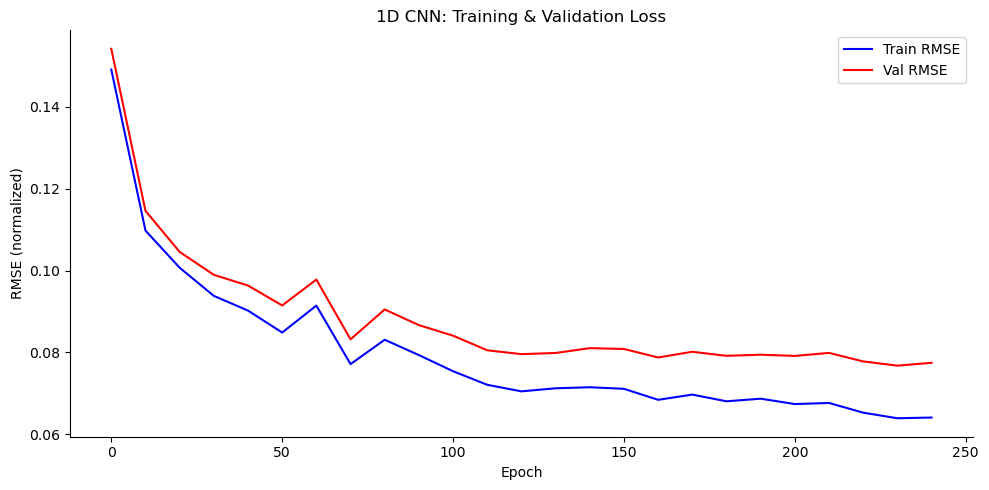

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(cnn_history['epoch'], cnn_history['train_rmse'], label='Train RMSE', color='blue')
ax.plot(cnn_history['epoch'], cnn_history['val_rmse'], label='Val RMSE', color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE (normalized)')
ax.set_title('1D CNN: Training & Validation Loss')
ax.legend()
sns.despine()
plt.tight_layout()
wandb.log({'cnn_loss_curves': wandb.Image(fig)})
plt.show()


### Evaluation — Unnormalized Metrics
Plot predicted vs measured [dH, Tm, dG₃₇] and log final metrics.


In [13]:
@torch.no_grad()
def cnn_get_predictions(model, loader, stats):
    model.eval()
    y_all, pred_all = [], []
    for x_batch, y_batch in loader:
        pred = model(x_batch.to(device))
        y_all.append(y_batch.numpy())
        pred_all.append(pred.cpu().numpy())
    y = np.concatenate(y_all)
    pred = np.concatenate(pred_all)
    y[:, 0] = unnormalize(y[:, 0], stats['dH_min'], stats['dH_max'])
    y[:, 1] = unnormalize(y[:, 1], stats['Tm_min'], stats['Tm_max'])
    pred[:, 0] = unnormalize(pred[:, 0], stats['dH_min'], stats['dH_max'])
    pred[:, 1] = unnormalize(pred[:, 1], stats['Tm_min'], stats['Tm_max'])
    return y, pred



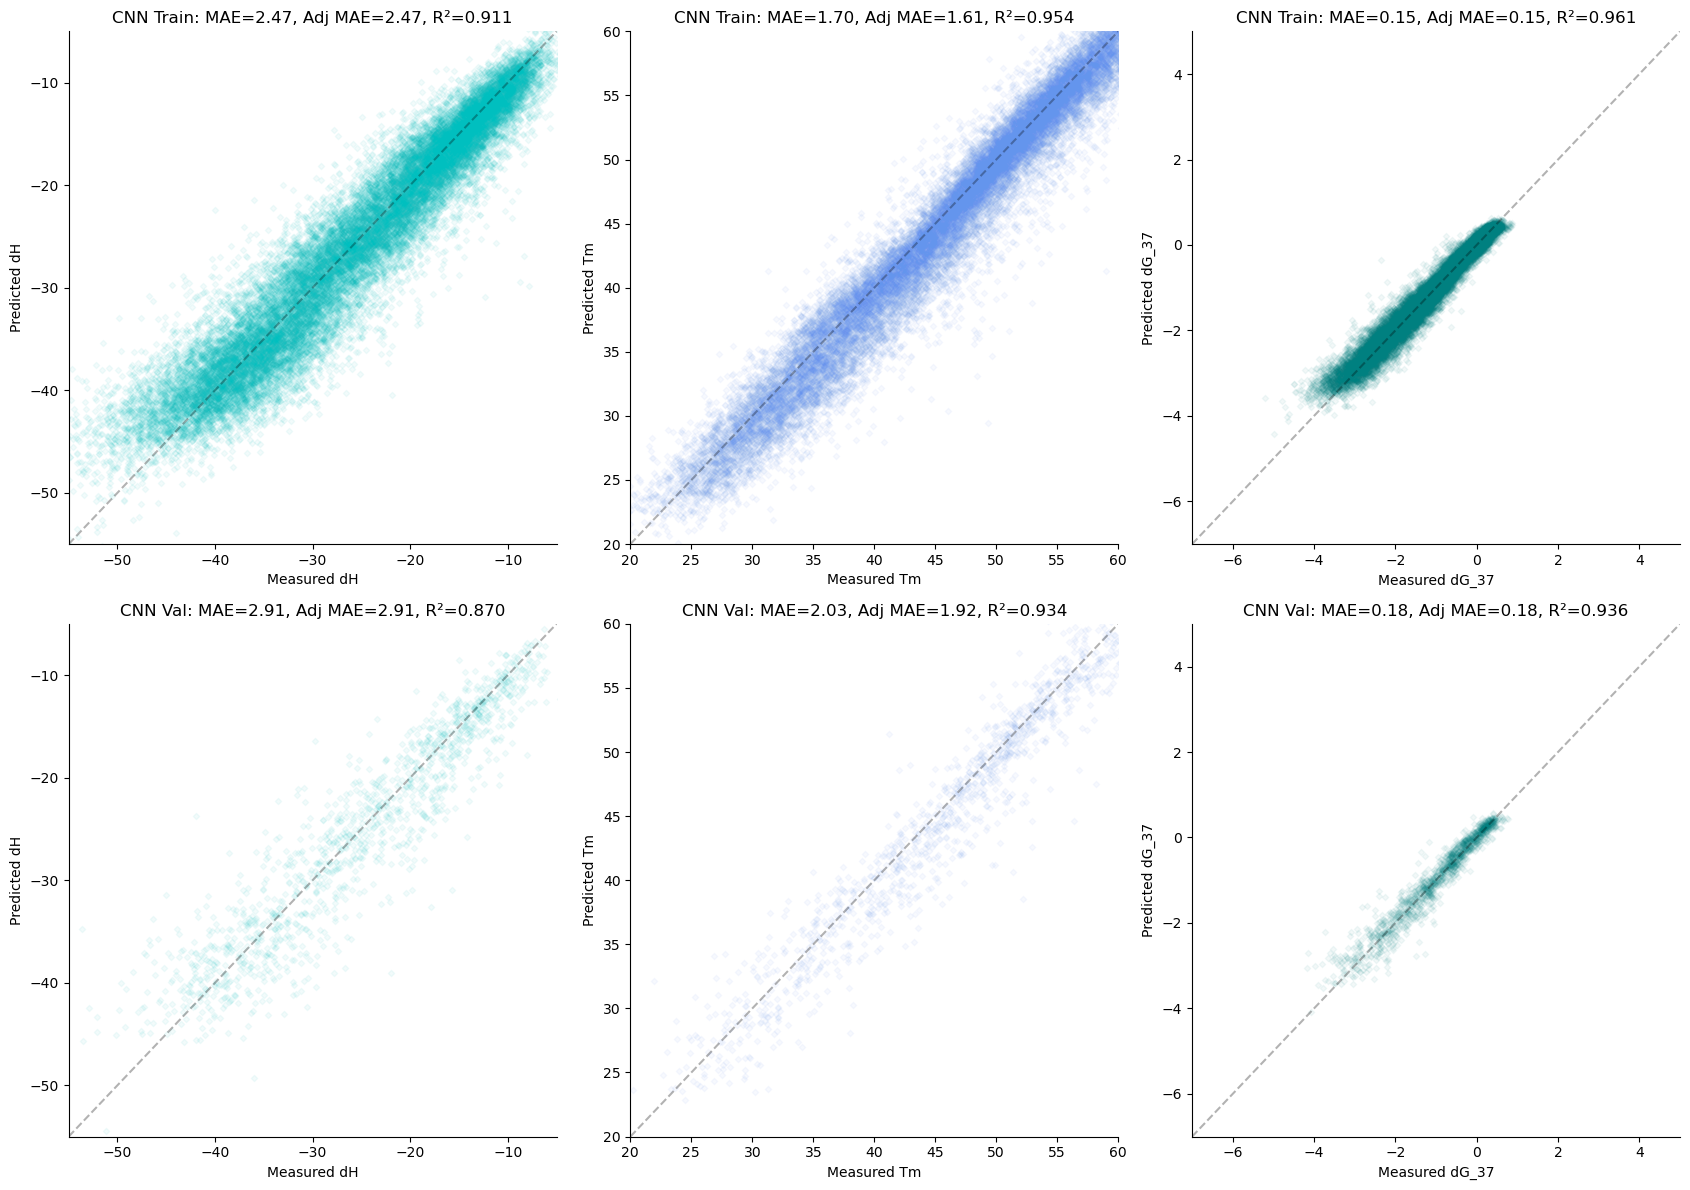

                     Validation Results                     
dH             2.9089     2.9082   3.9797   0.8698  -0.2041
Tm             2.0296     1.9211   2.7766   0.9340  -0.9361
dG_37          0.1826     0.1801   0.2616   0.9359   0.0384


cnn_train_rmse,█▅▄▃▃▃▃▂▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
cnn_val_rmse,█▄▄▃▃▂▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cnn_train_rmse,0.06408
cnn_val_rmse,0.07746


Saved wandb logs to MyExperiments/1DCNN/wandb/1DCNN_20260302_013044
Saved model to MyExperiments/1DCNN/models/1DCNN_20260302_013044/model.pt


In [15]:
from sklearn.metrics import r2_score

def calc_dG37(dH, Tm):
    return dH * (1 - (273.15 + 37) / (273.15 + Tm))

def plot_scatter(y, pred, ax, param_name, title, color, lim):
    mask = ~np.isnan(y)
    y, pred = y[mask], pred[mask]
    rmse = np.sqrt(np.mean((y - pred)**2))
    mae = np.mean(np.abs(y - pred))
    r2 = r2_score(y, pred)
    bias = np.mean(pred) - np.mean(y)
    pred_adj = pred - bias
    mae_adj = np.mean(np.abs(y - pred_adj))
    ax.scatter(y, pred, c=color, marker='D', alpha=0.05, s=10)
    ax.plot(lim, lim, 'k--', alpha=0.3)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel(f'Measured {param_name}')
    ax.set_ylabel(f'Predicted {param_name}')
    ax.set_title(f'{title}: MAE={mae:.2f}, Adj MAE={mae_adj:.2f}, R²={r2:.3f}')
    return dict(rmse=rmse, mae=mae, mae_adj=mae_adj, r2=r2, bias=bias)

cnn_train_y, cnn_train_pred = cnn_get_predictions(cnn_model, cnn_train_loader, stats)
cnn_val_y, cnn_val_pred = cnn_get_predictions(cnn_model, cnn_val_loader, stats)
fig, axes = plt.subplots(2, 3, figsize=(17, 12))
plot_scatter(cnn_train_y[:,0], cnn_train_pred[:,0], axes[0,0], 'dH', 'CNN Train', 'c', [-55,-5])
plot_scatter(cnn_train_y[:,1], cnn_train_pred[:,1], axes[0,1], 'Tm', 'CNN Train', 'cornflowerblue', [20,60])
cnn_train_dG = calc_dG37(cnn_train_y[:,0], cnn_train_y[:,1])
cnn_train_dG_pred = calc_dG37(cnn_train_pred[:,0], cnn_train_pred[:,1])
plot_scatter(cnn_train_dG, cnn_train_dG_pred, axes[0,2], 'dG_37', 'CNN Train', 'teal', [-7,5])
cnn_dH = plot_scatter(cnn_val_y[:,0], cnn_val_pred[:,0], axes[1,0], 'dH', 'CNN Val', 'c', [-55,-5])
cnn_Tm = plot_scatter(cnn_val_y[:,1], cnn_val_pred[:,1], axes[1,1], 'Tm', 'CNN Val', 'cornflowerblue', [20,60])
cnn_val_dG = calc_dG37(cnn_val_y[:,0], cnn_val_y[:,1])
cnn_val_dG_pred = calc_dG37(cnn_val_pred[:,0], cnn_val_pred[:,1])
cnn_dG = plot_scatter(cnn_val_dG, cnn_val_dG_pred, axes[1,2], 'dG_37', 'CNN Val', 'teal', [-7,5])
sns.despine()
plt.tight_layout()
wandb.log({'cnn_results': wandb.Image(fig)})
plt.show()
print('' + '='*60)
print('Validation Results'.center(60))
print('='*60)
for name, m in [('dH', cnn_dH), ('Tm', cnn_Tm), ('dG_37', cnn_dG)]:
    print(f"{name:<12} {m['mae']:>8.4f} {m['mae_adj']:>10.4f} {m['rmse']:>8.4f} {m['r2']:>8.4f} {m['bias']:>8.4f}")
wandb.finish()
model_dir = MODEL_ROOT / RUN_NAME
model_dir.mkdir(parents=True, exist_ok=True)
torch.save(cnn_model.state_dict(), model_dir / 'model.pt')
current_wandb_dir = RUN_DIR
if current_wandb_dir.exists():
    target_wandb_dir = WANDB_ROOT / RUN_NAME
    if target_wandb_dir.exists():
        shutil.rmtree(target_wandb_dir)
    shutil.move(str(current_wandb_dir), str(target_wandb_dir))
    print(f"Saved wandb logs to {target_wandb_dir}")
print(f"Saved model to {model_dir / 'model.pt'}")
